# Analyse des mobilités résidentielles entre villes françaises

Le fichier `edges_mobilites.csv` contient des paires `(source, target)` représentant des flux de personnes qui ont déménagé d'une ville à une autre. Chaque ligne correspond à un lien (une **arête**) du graphe.

## 1. Import des bibliothèques

In [1]:
from io import BytesIO
from zipfile import ZipFile
from urllib.request import urlopen
import warnings


import networkx as nx
import itertools
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import scipy.stats
from scipy.optimize import curve_fit

warnings.filterwarnings('ignore')
import community as community_louvain  # python-louvain


## 2. Chargement des données de mobilité

On charge le fichier CSV contenant les arêtes du graphe de mobilité.
- La colonne `source` = nom de la ville de départ
- La colonne `target` = nom de la ville d'arrivée

In [2]:
df = pd.read_csv(
    "edges_mobilites.csv",
    dtype={"source": str, "target": str}
)

print(df.head())
print(f"\nNombre total de liens de mobilité : {len(df):,}")

                    source                      target
0  L'Abergement-Clémenciat    Châtillon-sur-Chalaronne
1  L'Abergement-Clémenciat  Saint-Trivier-sur-Moignans
2  L'Abergement-Clémenciat                    Sulignat
3  L'Abergement-Clémenciat                   Vitrolles
4  L'Abergement-Clémenciat       Boucoiran-et-Nozières

Nombre total de liens de mobilité : 405,508


## 3. Construction du graphe orienté (DiGraph)

On utilise un **graphe orienté** (`DiGraph`) car les mobilités ont une direction.
Chaque **nœud** représente une ville, chaque **arête** représente un flux migratoire entre deux villes.

In [3]:
G = nx.from_pandas_edgelist(df, source="source", target="target", create_using=nx.DiGraph())

print(f"  - Nombre de nœuds (villes) : {G.number_of_nodes():,}")
print(f"  - Nombre d'arêtes (flux)   : {G.number_of_edges():,}")

  - Nombre de nœuds (villes) : 30,782
  - Nombre d'arêtes (flux)   : 404,835


## 4. Propriétés globales du graphe

### Densité du réseau
La **densité** mesure la fraction des connexions réellement présentes par rapport au nombre maximal possible.

$$\text{densité} = \frac{\text{nombre d'arêtes}}{N \times (N-1)}$$

où $N$ est le nombre de nœuds.

In [4]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)


print(f"Densité         : {density:.6f}")
print(f"\nSeulement {density*100:.4f}% des connexions possibles entre villes existent.")

Densité         : 0.000427

Seulement 0.0427% des connexions possibles entre villes existent.


## 5. Distribution des degrés

Le **degré** d'un nœud est le nombre de connexions qu'il possède (ici : nombre de villes reliées par des flux migratoires).

On définit deux fonctions :
- `logBinning` : regroupe les données en **intervalles logarithmiques**, ce qui est nécessaire pour visualiser une loi de puissance sur plusieurs ordres de grandeur.
- `powerLaw` : définit la forme $P(k) = b \cdot k^a$ pour ajuster une loi de puissance.

In [5]:
def logBinning(degreeList, nbin):
    """Découpe la distribution en intervalles logarithmiques."""
    kmin = min(degreeList)
    kmax = max(degreeList)
    logBins = np.logspace(np.log10(kmin), np.log10(kmax), num=nbin)
    logBinDensity, binedges = np.histogram(degreeList, bins=logBins, density=True)
    logBins = np.delete(logBins, -1)
    return logBinDensity, logBins

def powerLaw(x, a, b):
    """Loi de puissance : P(k) = b * k^a."""
    return b * x**(a)

### 5.1 Histogramme brut des degrés

On commence par un histogramme simple. La distribution est très **asymétrique** : la grande majorité des villes ont peu de connexions, mais quelques grandes villes (hubs) en ont beaucoup.

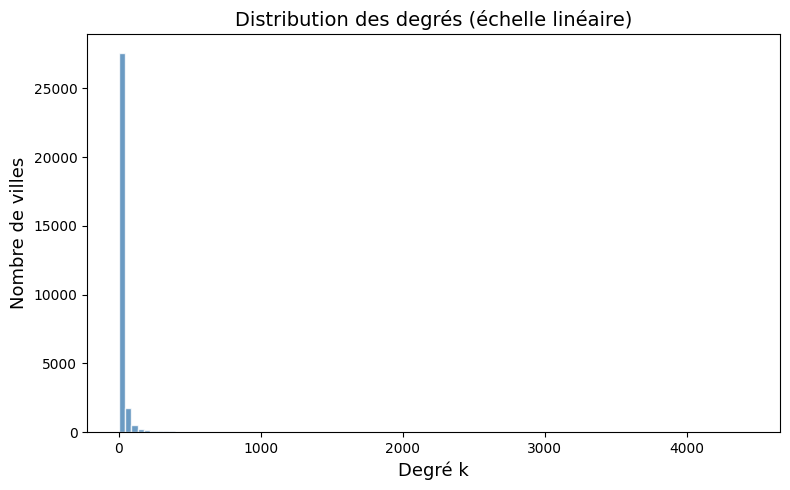

Degré minimum : 1
Degré maximum : 4435
Degré moyen   : 26.3


In [6]:
# Calcul des degrés de tous les nœuds
kDict = dict(G.degree())
kValues = list(kDict.values())

plt.figure(figsize=(8, 5))
plt.hist(kValues, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
plt.xlabel('Degré k', size=13)
plt.ylabel('Nombre de villes', size=13)
plt.title('Distribution des degrés (échelle linéaire)', size=14)
plt.tight_layout()
plt.show()

print(f"Degré minimum : {min(kValues)}")
print(f"Degré maximum : {max(kValues)}")
print(f"Degré moyen   : {np.mean(kValues):.1f}")

### 5.2 Distribution en log-log et loi de puissance

En échelle log-log, si la distribution suit une **loi de puissance** $P(k) \sim k^{-\gamma}$, on obtient une droite.

Exposant γ estimé : -2.530


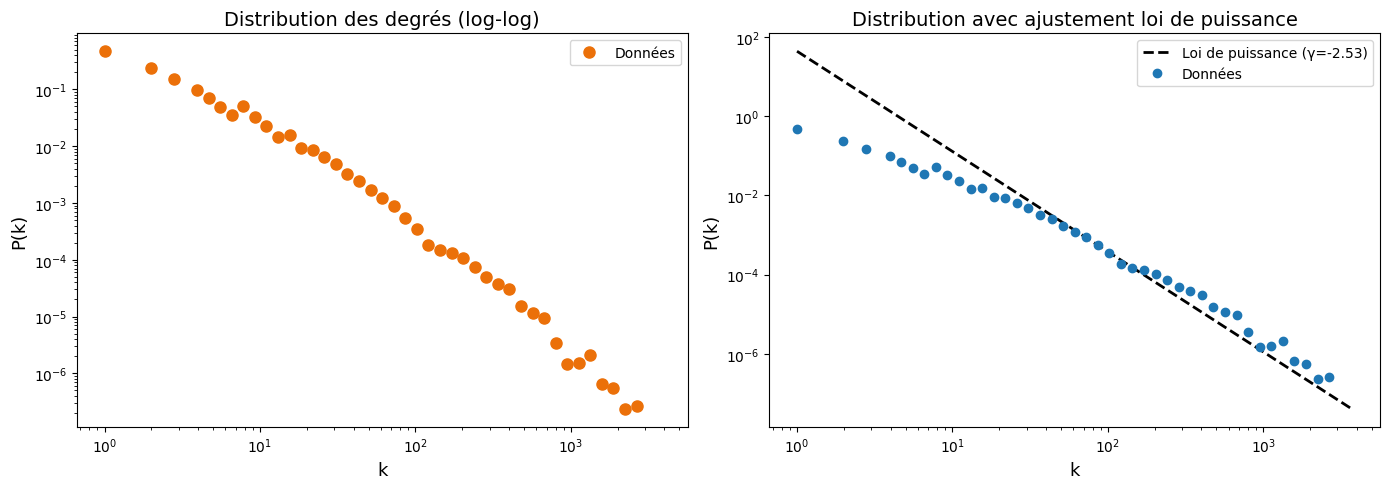

In [7]:
pk, k = logBinning(kValues, 50)

fitx = [u for (u, v) in zip(k, pk) if (u > 70 and u < 1000)]
fity = [v for (u, v) in zip(k, pk) if (u > 70 and u < 1000)]

popt, pcov = curve_fit(powerLaw, fitx, fity)
gamma = popt[0]
print(f"Exposant γ estimé : {gamma:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution log-log
axes[0].loglog(k, pk, 'o', color='#EB7009', markersize=8, label='Données')
axes[0].set_xlabel('k', size=13)
axes[0].set_ylabel('P(k)', size=13)
axes[0].set_title('Distribution des degrés (log-log)', size=14)
axes[0].legend()

# Avec ajustement
axes[1].loglog(sorted(k), powerLaw(sorted(k), *popt), '--', c='k',
               linewidth=2, label=f'Loi de puissance (γ={gamma:.2f})')
axes[1].loglog(k, pk, 'o', label='Données')
axes[1].set_xlabel('k', size=13)
axes[1].set_ylabel('P(k)', size=13)
axes[1].set_title('Distribution avec ajustement loi de puissance', size=14)
axes[1].legend()

plt.tight_layout()
plt.show()

Exposant $\gamma ≈ -2.5$ (pente de la droite en log-log)

Cet exposant est caractéristique des **réseaux sans échelle** (*scale-free networks*), comme observé dans de nombreux réseaux sociaux et géographiques. Cela signifie :
- La majorité des villes ont peu de connexions
- Quelques grandes métropoles jouent un rôle de **hub** dans les mobilités nationales

## 6. Analyse des corrélations de degrés : knn(k)

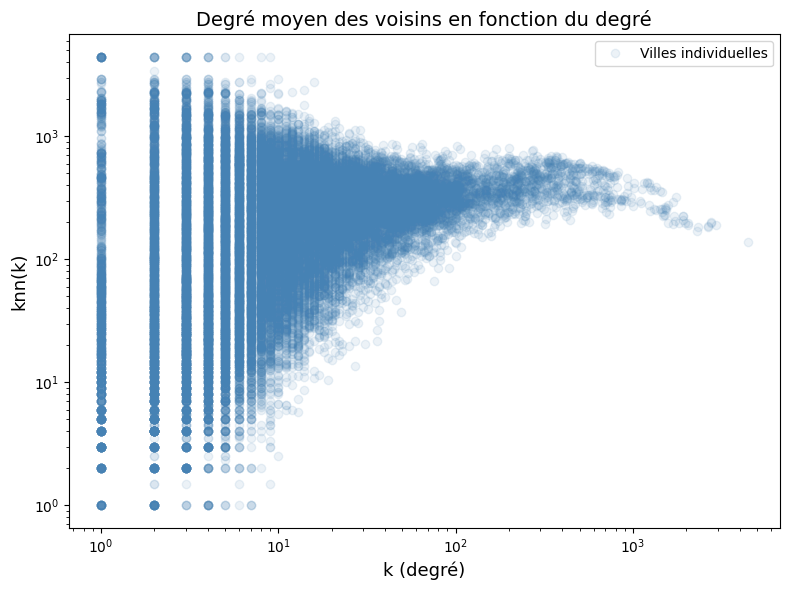

In [8]:
# Calcul du degré moyen des voisins pour chaque nœud
knn = {}
for n in G.nodes():
    neighbors_degrees = [kDict[v] for v in G.neighbors(n)]
    knn[n] = np.mean(neighbors_degrees)

xx = [kDict[n] for n in knn.keys()]
yy = [knn[n] for n in knn.keys()]

plt.figure(figsize=(8, 6))
plt.loglog(xx, yy, 'o', alpha=0.1, color='steelblue', label='Villes individuelles')
plt.xlabel('k (degré)', size=13)
plt.ylabel('knn(k)', size=13)
plt.title('Degré moyen des voisins en fonction du degré', size=14)
plt.legend()
plt.tight_layout()
plt.show()

---

# PARTIE 2 : Intégration des volumes de migration
Le fichier de migrations contient ces colonnes :
- `source` : code INSEE de la ville de départ
- `target` : code INSEE de la ville d'arrivée  
- `nb_migrations` (ou un nom similaire) : nombre de personnes ayant effectué ce déplacement

## Étape 1 : Chargement du fichier de migrations

In [9]:
df_merged = pd.read_csv(
     "edges_mobilites_nb.csv",  # <-- adaptez le nom du fichier
     dtype={"source": str, "target": str, "nb_migrations": float}
)
print(df_merged.head())
print(f"\nVolume total de migrations : {df_merged['nb_migrations'].sum():,}")

                    source                      target  nb_migrations
0  L'Abergement-Clémenciat    Châtillon-sur-Chalaronne       9.817143
1  L'Abergement-Clémenciat  Saint-Trivier-sur-Moignans       4.908571
2  L'Abergement-Clémenciat                    Sulignat      19.634286
3  L'Abergement-Clémenciat                   Vitrolles      19.634286
4  L'Abergement-Clémenciat       Boucoiran-et-Nozières       4.908571

Volume total de migrations : 4,264,241.137821711


## Étape 2 : Construction du graphe pondéré

On reconstruit le graphe en ajoutant le volume comme **poids des arêtes**. Cela permet d'analyser non seulement la présence d'un lien, mais aussi son intensité.

In [10]:
# Construction du graphe pondéré
G_weighted = nx.from_pandas_edgelist(
    df_merged,
    source='source',
    target='target',
    edge_attr='nb_migrations',
    create_using=nx.DiGraph()
)

print(f"Graphe pondéré construit :")
print(f"  - Nœuds : {G_weighted.number_of_nodes():,}")
print(f"  - Arêtes avec poids : {G_weighted.number_of_edges():,}")

Graphe pondéré construit :
  - Nœuds : 30,782
  - Arêtes avec poids : 404,835


## Étape 3 : Analyse de la force des nœuds (strength)

Dans un graphe pondéré, on distingue :
- **Degré** : nombre de connexions,
- **Force** : somme des poids des connexions = volume total de migration.

La force mesure l'**importance réelle** d'une ville dans les mobilités.

In [11]:
# Calcul de la force de chaque nœud
strength = dict(G_weighted.degree(weight='nb_migrations'))
strength_values = list(strength.values())

# Top 10 des villes par volume de mobilité
top10_strength = sorted(strength.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 des villes par volume total de migrations :")
for rank, (city, s) in enumerate(top10_strength, 1):
    degree = G_weighted.degree(city)
    print(f"{rank:2}. Ville {city} | Force: {s:6,} | Degré: {degree:4}")

print()
print("Force totale du réseau :", f"{sum(strength_values):,}")

Top 10 des villes par volume total de migrations :
 1. Ville Toulouse | Force: 71,306.50905817833 | Degré: 4435
 2. Ville Nantes | Force: 49,415.773035058315 | Degré: 2751
 3. Ville Bordeaux | Force: 48,327.87366698848 | Degré: 2749
 4. Ville Montpellier | Force: 44,071.13954584751 | Degré: 2939
 5. Ville Lille | Force: 42,151.033759411934 | Degré: 2660
 6. Ville Rennes | Force: 39,943.19982337815 | Degré: 2649
 7. Ville Paris 15e Arrondissement | Force: 38,440.62002010301 | Degré: 1758
 8. Ville Strasbourg | Force: 31,601.48219482466 | Degré: 2333
 9. Ville Paris 18e Arrondissement | Force: 28,116.995499367906 | Degré: 1352
10. Ville Grenoble | Force: 26,972.070443996938 | Degré: 1910

Force totale du réseau : 8,509,284.07629512


## Étape 4 : Relation degré / force

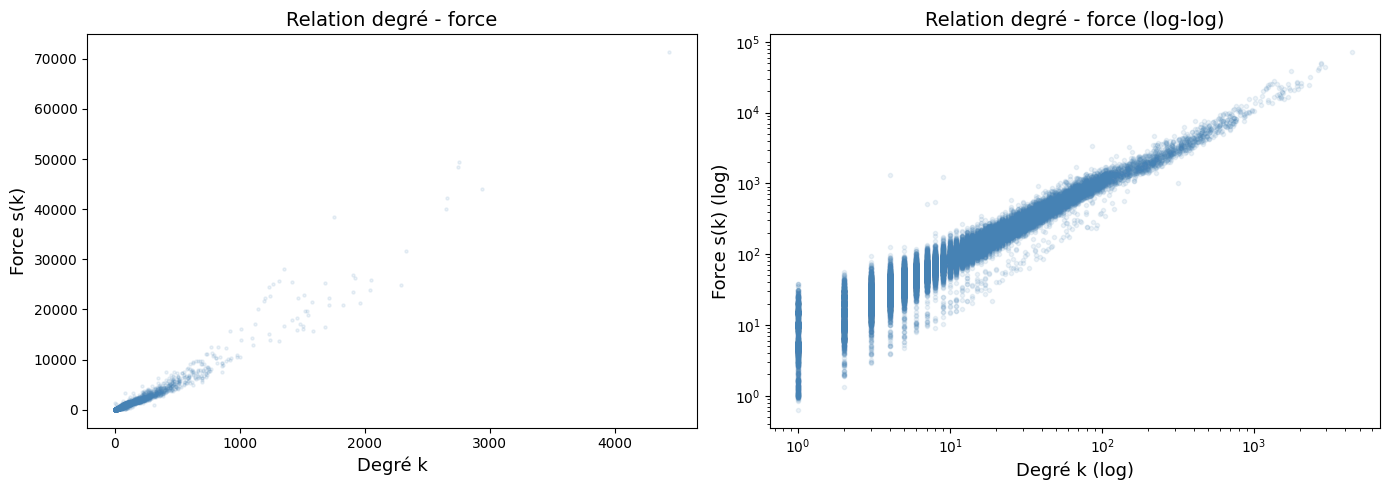

In [12]:
degree_vals = [G_weighted.degree(n) for n in G_weighted.nodes()]
strength_vals = [strength[n] for n in G_weighted.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(degree_vals, strength_vals, alpha=0.1, s=5, color='steelblue')
axes[0].set_xlabel('Degré k', size=13)
axes[0].set_ylabel('Force s(k)', size=13)
axes[0].set_title('Relation degré - force', size=14)

# En log-log
axes[1].loglog(degree_vals, strength_vals, 'o', alpha=0.1, markersize=3, color='steelblue')
axes[1].set_xlabel('Degré k (log)', size=13)
axes[1].set_ylabel('Force s(k) (log)', size=13)
axes[1].set_title('Relation degré - force (log-log)', size=14)

plt.tight_layout()
plt.show()

## Étape 5 : Analyse des flux dominants

On identifie les **corridors migratoires les plus importants** : les paires de villes avec les plus grands volumes de migration.

In [13]:
# Top 20 des flux migratoires
edges_with_weight = [
    (u, v, d['nb_migrations'])
    for u, v, d in G_weighted.edges(data=True)
]
top20_flows = sorted(edges_with_weight, key=lambda x: x[2], reverse=True)[:20]

print("Top 20 des corridors migratoires :")
print("-" * 50)
print(f"{'Rang':>4} | {'Départ':>7} → {'Arrivée':>7} | {'Migrations':>10}")
print("-" * 50)
for rank, (src, tgt, vol) in enumerate(top20_flows, 1):
    print(f"{rank:4} | {src:>7} → {tgt:>7} | {vol:>10,}")

Top 20 des corridors migratoires :
--------------------------------------------------
Rang |  Départ → Arrivée | Migrations
--------------------------------------------------
   1 | Mérignac → Bordeaux | 1,599.60122852842
   2 | Sainte-Florence → Essarts-en-Bocage | 1,318.10054285679
   3 | Villeurbanne → Lyon 3e Arrondissement | 1,237.90614432366
   4 | Saint-Herblain →  Nantes | 1,206.26761861947
   5 | Talence → Bordeaux | 1,189.51289103241
   6 |   L'Oie → Essarts-en-Bocage | 1,178.77130203621
   7 |    Rezé →  Nantes | 1,023.9466155915
   8 |  Bègles → Bordeaux | 1,002.02881162316
   9 | Schiltigheim → Strasbourg | 1,000.5300138883
  10 | Castelnau-le-Lez → Montpellier | 981.206439687231
  11 | Lyon 3e Arrondissement → Villeurbanne | 976.789016268191
  12 | Paris 20e Arrondissement → Paris 11e Arrondissement | 945.139070643315
  13 | Lyon 3e Arrondissement → Lyon 7e Arrondissement | 932.697427375749
  14 | Paris 15e Arrondissement → Paris 14e Arrondissement | 887.125282410425
  15

## Étape 6 : Distribution des volumes de migration

On analyse la distribution statistique des volumes de migration par lien.

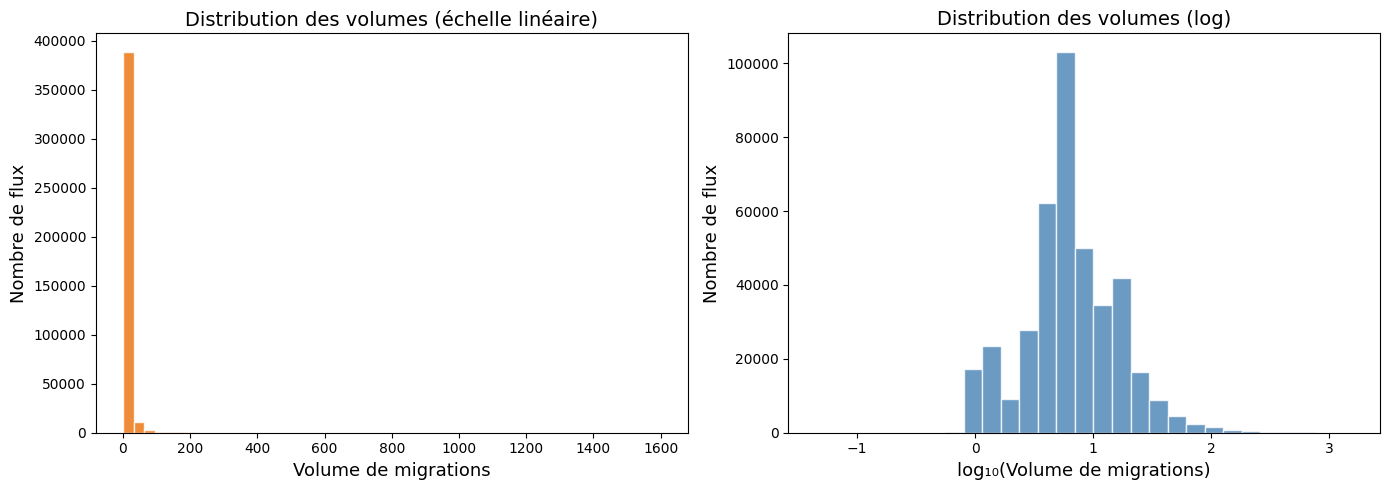

Volume moyen par flux : 11 personnes
Volume médian par flux : 5 personnes
Volume maximum : 1,599.60122852842 personnes


In [14]:
volumes = [d['nb_migrations'] for u, v, d in G_weighted.edges(data=True)]
volumes = [v for v in volumes if v > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme linéaire
axes[0].hist(volumes, bins=50, color='#EB7009', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Volume de migrations', size=13)
axes[0].set_ylabel('Nombre de flux', size=13)
axes[0].set_title('Distribution des volumes (échelle linéaire)', size=14)

# Histogramme log-log
log_volumes = np.log10([v for v in volumes if v > 0])
bins = np.linspace(min(log_volumes), max(log_volumes), 30)
axes[1].hist(log_volumes, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('log₁₀(Volume de migrations)', size=13)
axes[1].set_ylabel('Nombre de flux', size=13)
axes[1].set_title('Distribution des volumes (log)', size=14)

plt.tight_layout()
plt.show()

print(f"Volume moyen par flux : {np.mean(volumes):.0f} personnes")
print(f"Volume médian par flux : {np.median(volumes):.0f} personnes")
print(f"Volume maximum : {max(volumes):,} personnes")

---
# PARTIE 3 : Détection de communautés

Les **communautés** sont des groupes de villes plus densément connectées entre elles qu'avec le reste du réseau. Dans le contexte des migrations résidentielles, elles correspondent à des **zones d'attraction migratoire** : des bassins dans lesquels les gens migrent préférentiellement, révélant des logiques de proximité géographique, économique ou culturelle.

Deux méthodes complémentaires sont proposées :
- **Algorithme de Louvain** : rapide, basé sur l'optimisation de la modularité, recommandé pour les grands graphes
- **Girvan-Newman** : basé sur la suppression itérative des arêtes à forte centralité, plus interprétable mais plus coûteux en calcul

In [15]:
# Chargement des flux (graphe non pondéré)
df = pd.read_csv(
    "edges_mobilites.csv",
    dtype={"source": str, "target": str}
)

# Chargement des flux avec volumes (graphe pondéré)
df_weighted = pd.read_csv(
    "edges_mobilites_nb.csv",
    dtype={"source": str, "target": str, "nb_migrations": float}
)

In [16]:
# Construction des graphes
G = nx.from_pandas_edgelist(df, source="source", target="target", create_using=nx.DiGraph())

G_weighted = nx.from_pandas_edgelist(
    df_weighted,
    source='source',
    target='target',
    edge_attr='nb_migrations',
    create_using=nx.DiGraph()
)

# Graphe non orienté (nécessaire pour la détection de communautés)
G_undirected = G.to_undirected()
G_weighted_undirected = G_weighted.to_undirected(reciprocal=False)

## 1.1 Algorithme de Louvain sur le graph _non_ pondéré

In [17]:
# Détection des communautés avec l'algorithme de Louvain
partition = community_louvain.best_partition(G_undirected, resolution=1.0, random_state=42)

# Calcul de la modularité
modularity = community_louvain.modularity(partition, G_undirected)

# Statistiques sur les communautés
n_communities = len(set(partition.values()))
community_sizes = pd.Series(partition.values()).value_counts().sort_values(ascending=False)

print(f"Nombre de communautés détectées : {n_communities}")
print(f"Modularité Q                    : {modularity:.4f}")
print(f"\nTop 10 des communautés par taille :")
print("-" * 35)
for comm_id, size in community_sizes.head(10).items():
    print(f"  Communauté {comm_id:3d} : {size:4d} villes")

Nombre de communautés détectées : 30
Modularité Q                    : 0.5140

Top 10 des communautés par taille :
-----------------------------------
  Communauté  21 : 5731 villes
  Communauté   8 : 3735 villes
  Communauté   2 : 3650 villes
  Communauté   5 : 3583 villes
  Communauté  20 : 3361 villes
  Communauté   3 : 3145 villes
  Communauté   4 : 2524 villes
  Communauté   9 : 2389 villes
  Communauté  12 : 1449 villes
  Communauté   6 : 1175 villes


In [18]:
# Analyse des communautés majeures
major_communities = community_sizes[community_sizes >= community_sizes.quantile(0.75)].index.tolist()

print("Communautés majeures (>= 75e percentile de taille) :")
print("-" * 55)

for comm_id in major_communities[:10]:
    # Villes de cette communauté
    cities_in_comm = [node for node, c in partition.items() if c == comm_id]
    size = len(cities_in_comm)

    # Degré moyen des villes de la communauté
    degrees = [G_undirected.degree(c) for c in cities_in_comm]
    avg_degree = np.mean(degrees)

    # Ville centrale (hub) = ville avec le plus fort degré dans la communauté
    hub = cities_in_comm[np.argmax(degrees)]

    print(f"  Communauté {comm_id:3d} | {size:4d} villes | Degré moyen : {avg_degree:.1f} | Hub : {hub}")

Communautés majeures (>= 75e percentile de taille) :
-------------------------------------------------------
  Communauté  21 | 5731 villes | Degré moyen : 20.4 | Hub : Dijon
  Communauté   8 | 3735 villes | Degré moyen : 14.3 | Hub : Strasbourg
  Communauté   2 | 3650 villes | Degré moyen : 18.7 | Hub : Toulouse
  Communauté   5 | 3583 villes | Degré moyen : 20.4 | Hub : Bordeaux
  Communauté  20 | 3361 villes | Degré moyen : 45.0 | Hub : Reims
  Communauté   3 | 3145 villes | Degré moyen : 17.2 | Hub : Lille
  Communauté   4 | 2524 villes | Degré moyen : 31.3 | Hub : Nantes
  Communauté   9 | 2389 villes | Degré moyen : 16.1 | Hub : Rouen


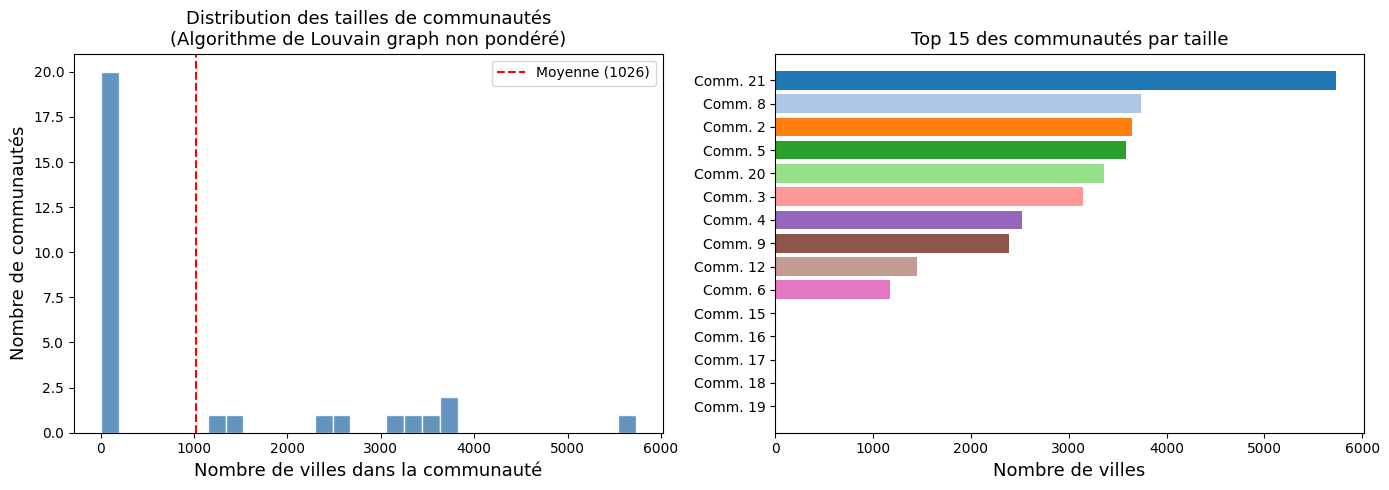


Modularité Q = 0.5140


In [29]:
# Distribution de la taille des communautés
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des tailles
axes[0].hist(community_sizes.values, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Nombre de villes dans la communauté', size=13)
axes[0].set_ylabel('Nombre de communautés', size=13)
axes[0].set_title('Distribution des tailles de communautés\n(Algorithme de Louvain graph non pondéré)', size=13)
axes[0].axvline(community_sizes.mean(), color='red', linestyle='--', label=f'Moyenne ({community_sizes.mean():.0f})')
axes[0].legend()

# Top 15 des communautés
top15 = community_sizes.head(15)
colors = plt.cm.tab20(np.linspace(0, 1, len(top15)))
axes[1].barh([f"Comm. {i}" for i in top15.index], top15.values, color=colors)
axes[1].set_xlabel('Nombre de villes', size=13)
axes[1].set_title('Top 15 des communautés par taille', size=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nModularité Q = {modularity:.4f}")

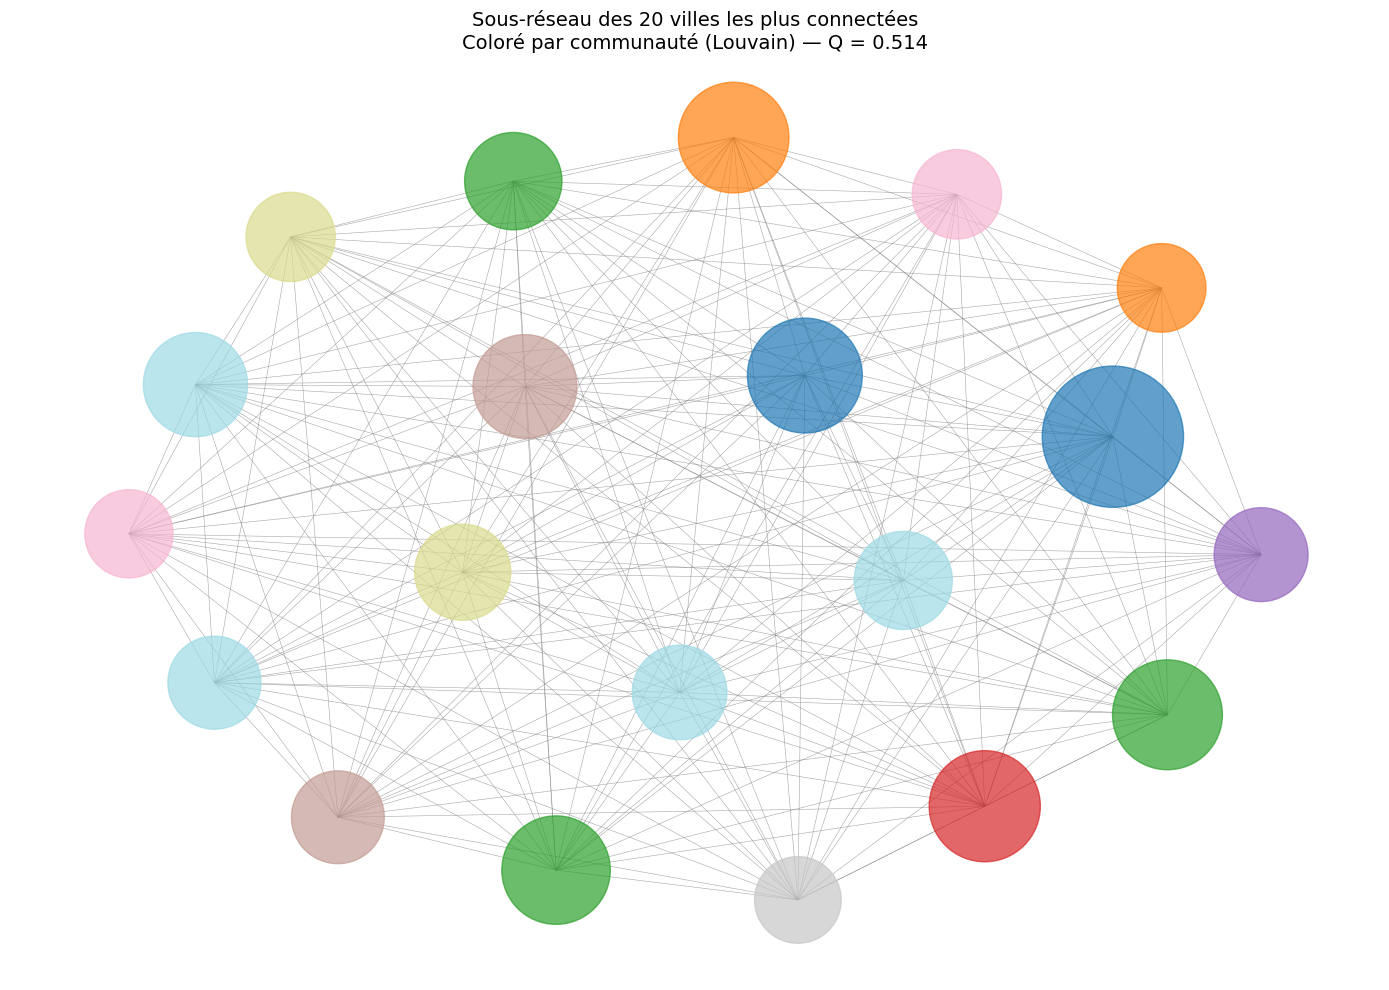

In [ ]:
# Visualisation du réseau coloré par communauté (sous-graphe des nœuds les plus connectés)
# On extrait les 20 villes les plus connectées
N_TOP = 20
top_nodes = sorted(G_undirected.degree(), key=lambda x: x[1], reverse=True)[:N_TOP]
top_node_names = [n for n, d in top_nodes]

H = G_undirected.subgraph(top_node_names)

# Couleurs par communauté
unique_communities = list(set(partition[n] for n in H.nodes()))
color_map = plt.cm.tab20(np.linspace(0, 1, len(unique_communities)))
comm_to_color = {c: color_map[i] for i, c in enumerate(unique_communities)}
node_colors = [comm_to_color[partition[n]] for n in H.nodes()]

# Taille des nœuds proportionnelle au degré
node_sizes = [G_undirected.degree(n) * 3 for n in H.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42, k=0.8)
nx.draw_networkx(
    H, pos=pos,
    node_color=node_colors,
    node_size=node_sizes,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.4,
    ax=ax
)
ax.set_title(
    f"Sous-réseau des {N_TOP} villes les plus connectées\nColoré par communauté (Louvain) — Q = {modularity:.3f}",
    size=14
)
ax.axis('off')
plt.tight_layout()
plt.show()

## 1.2 Louvain sur le graphe pondéré

Maintenant on utilise les **poids des arêtes** (i.e. le nombre de migrations) dans la détection de communautés.

In [26]:
# Détection sur le graphe pondéré
partition_w = community_louvain.best_partition(
    G_weighted_undirected,
    weight='nb_migrations',
    resolution=1.0,
    random_state=42
)
modularity_w = community_louvain.modularity(partition_w, G_weighted_undirected, weight='nb_migrations')
n_communities_w = len(set(partition_w.values()))
community_sizes_w = pd.Series(partition_w.values()).value_counts().sort_values(ascending=False)

print("=== Louvain non pondéré ===")
print(f"  Communautés : {n_communities}     | Modularité Q = {modularity:.4f}")
print()
print("=== Louvain pondéré (volumes de migration) ===")
print(f"  Communautés : {n_communities_w}     | Modularité Q = {modularity_w:.4f}")
print()

# Calcul du NMI (Normalized Mutual Information) comme mesure de similarité entre les
# communautés obtenues entre les deux graphs.
from sklearn.metrics import normalized_mutual_info_score
common_nodes = list(set(partition.keys()) & set(partition_w.keys()))
labels_a = [partition[n] for n in common_nodes]
labels_b = [partition_w[n] for n in common_nodes]
nmi = normalized_mutual_info_score(labels_a, labels_b)
print(f"Similarité entre partitionnements (NMI) : {nmi:.4f}")

=== Louvain non pondéré ===
  Communautés : 30     | Modularité Q = 0.5140

=== Louvain pondéré (volumes de migration) ===
  Communautés : 41     | Modularité Q = 0.6260

Similarité entre partitionnements (NMI) : 0.6597


In [28]:
# Analyse des communautés majeures
major_communities = community_sizes_w[community_sizes_w >= community_sizes_w.quantile(0.75)].index.tolist()

print("Communautés majeures (>= 75e percentile de taille) :")
print("-" * 55)

for comm_id in major_communities[:10]:
    # Villes de cette communauté
    cities_in_comm = [node for node, c in partition.items() if c == comm_id]
    size = len(cities_in_comm)

    # Degré moyen des villes de la communauté
    degrees = [G_undirected.degree(c) for c in cities_in_comm]
    avg_degree = np.mean(degrees)

    # Ville centrale (hub) = ville avec le plus fort degré dans la communauté
    hub = cities_in_comm[np.argmax(degrees)]

    print(f"  Communauté {comm_id:3d} | {size:4d} villes | Degré moyen : {avg_degree:.1f} | Hub : {hub}")

Communautés majeures (>= 75e percentile de taille) :
-------------------------------------------------------
  Communauté   8 | 3735 villes | Degré moyen : 14.3 | Hub : Strasbourg
  Communauté  23 |    2 villes | Degré moyen : 1.0 | Hub : Malleret
  Communauté   4 | 2524 villes | Degré moyen : 31.3 | Hub : Nantes
  Communauté   3 | 3145 villes | Degré moyen : 17.2 | Hub : Lille
  Communauté  24 |    2 villes | Degré moyen : 1.0 | Hub : Mont-lès-Lamarche
  Communauté   9 | 2389 villes | Degré moyen : 16.1 | Hub : Rouen
  Communauté  18 |    2 villes | Degré moyen : 1.0 | Hub : Arsonval
  Communauté  10 |    2 villes | Degré moyen : 1.0 | Hub : Longeaux
  Communauté  21 | 5731 villes | Degré moyen : 20.4 | Hub : Dijon
  Communauté   1 |    2 villes | Degré moyen : 1.0 | Hub : Saudron


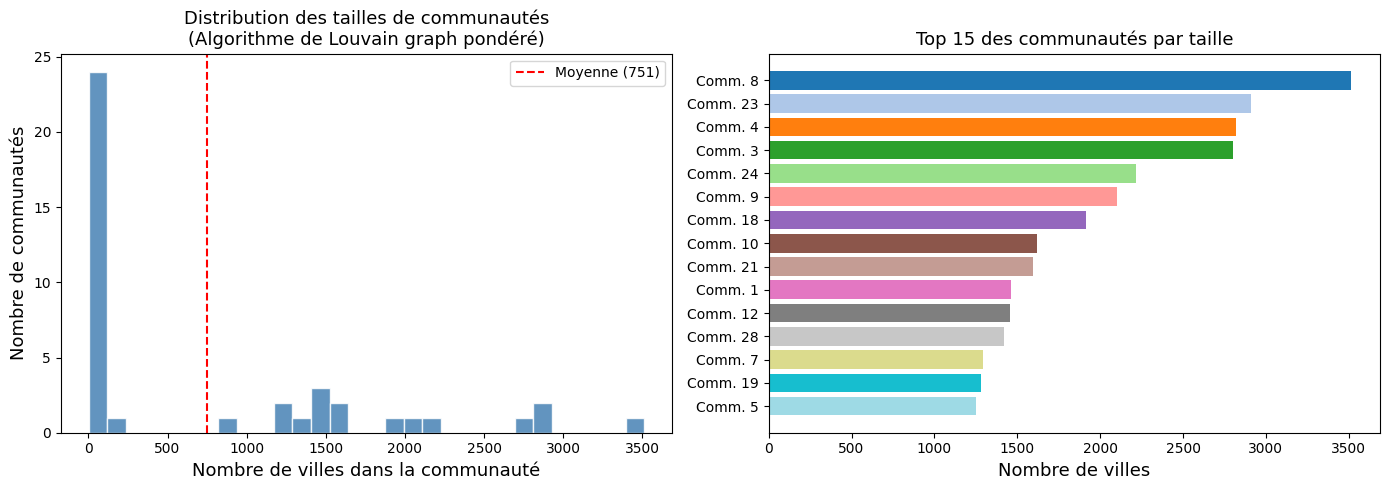


Modularité Q = 0.6260


In [32]:
# Distribution de la taille des communautés
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des tailles
axes[0].hist(community_sizes_w.values, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Nombre de villes dans la communauté', size=13)
axes[0].set_ylabel('Nombre de communautés', size=13)
axes[0].set_title('Distribution des tailles de communautés\n(Algorithme de Louvain graph pondéré)', size=13)
axes[0].axvline(community_sizes_w.mean(), color='red', linestyle='--', label=f'Moyenne ({community_sizes_w.mean():.0f})')
axes[0].legend()

# Top 15 des communautés
top15 = community_sizes_w.head(15)
colors = plt.cm.tab20(np.linspace(0, 1, len(top15)))
axes[1].barh([f"Comm. {i}" for i in top15.index], top15.values, color=colors)
axes[1].set_xlabel('Nombre de villes', size=13)
axes[1].set_title('Top 15 des communautés par taille', size=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nModularité Q = {modularity_w:.4f}")

## 1.3 Méthode Girvan-Newman

La méthode **Girvan-Newman** détecte les communautés en retirant itérativement les arêtes ayant la plus haute **centralité d'intermédiarité**. Ces arêtes sont celles qui servent de «ponts» entre des groupes de villes.

In [36]:
# Sous-graphe des villes les plus connectées pour Girvan-Newman
N_GN = 200  # Ajustez selon votre puissance de calcul (50-200 recommandé)

top_nodes_gn = sorted(G_undirected.degree(), key=lambda x: x[1], reverse=True)[:N_GN]
top_node_names_gn = [n for n, d in top_nodes_gn]
H_gn = G_undirected.subgraph(top_node_names_gn).copy()

print(f"Sous-graphe Girvan-Newman : {H_gn.number_of_nodes()} nœuds, {H_gn.number_of_edges()} arêtes")

Sous-graphe Girvan-Newman : 200 nœuds, 13250 arêtes


In [37]:
from networkx.algorithms.community import girvan_newman

# Exécution de Girvan-Newman — on s'arrête à k_target communautés
k_target = 4

gn_generator = girvan_newman(H_gn)

# Itération jusqu'au nombre de communautés souhaité
for communities_gn in gn_generator:
    if len(communities_gn) >= k_target:
        break

# Calcul de la modularité
modularity_gn = nx.community.modularity(H_gn, communities_gn)

print(f"Nombre de communautés détectées : {len(communities_gn)}")
print(f"Modularité Q                    : {modularity_gn:.4f}")
print()
print("Taille des communautés :")
for i, comm in enumerate(sorted(communities_gn, key=len, reverse=True)):
    print(f"  Communauté {i+1} : {len(comm)} villes")

Nombre de communautés détectées : 4
Modularité Q                    : -0.0000

Taille des communautés :
  Communauté 1 : 197 villes
  Communauté 2 : 1 villes
  Communauté 3 : 1 villes
  Communauté 4 : 1 villes


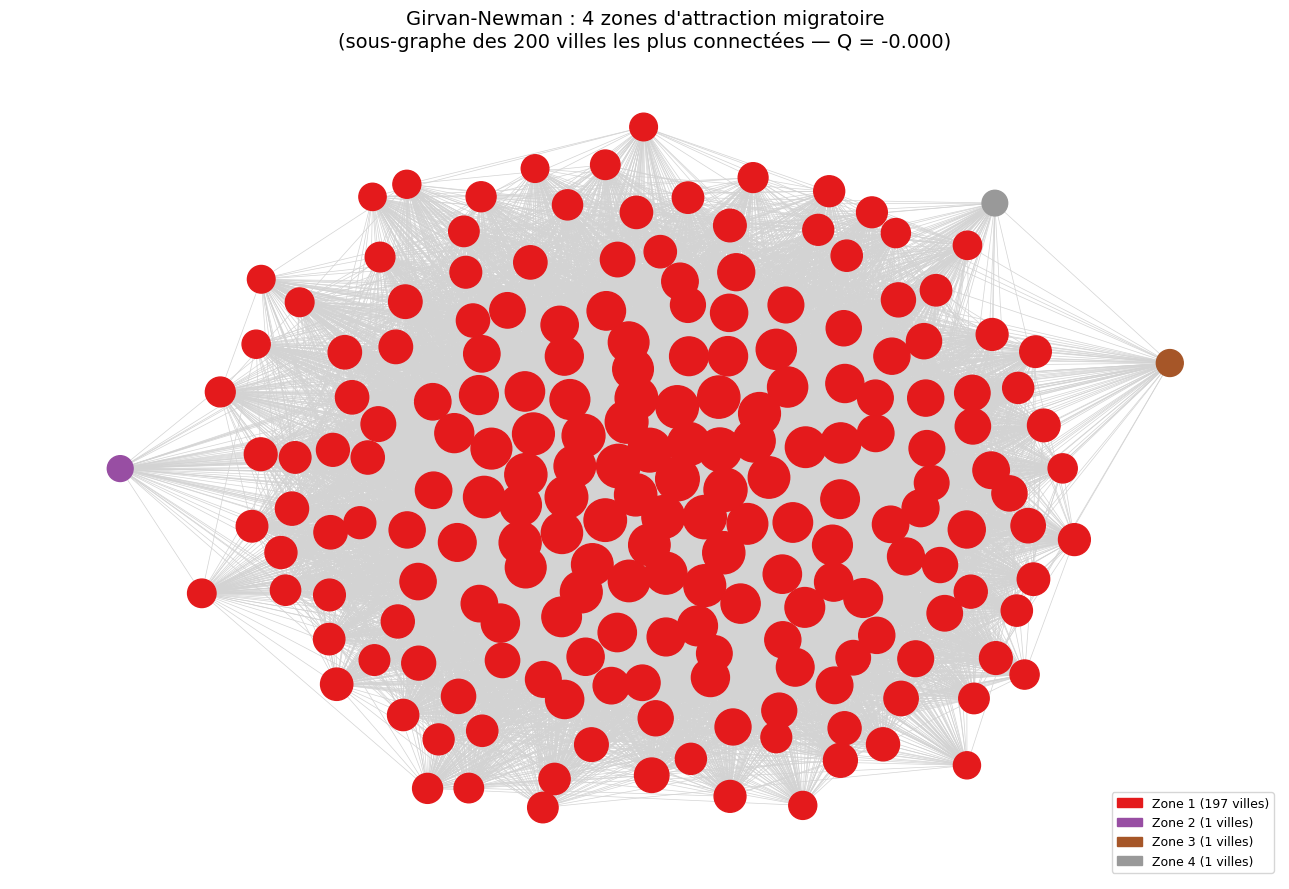

In [38]:
fig, ax = plt.subplots(figsize=(13, 9))

color_palette = plt.cm.Set1(np.linspace(0, 1, len(communities_gn)))
node_to_color_gn = {}
for i, comm in enumerate(communities_gn):
    for node in comm:
        node_to_color_gn[node] = color_palette[i]

colors_gn = [node_to_color_gn[n] for n in H_gn.nodes()]
sizes_gn = [H_gn.degree(n) * 5 for n in H_gn.nodes()]

pos_gn = nx.spring_layout(H_gn, seed=0, k=1.2)
nx.draw_networkx(
    H_gn, pos=pos_gn,
    node_color=colors_gn,
    node_size=sizes_gn,
    with_labels=False,
    edge_color='lightgray',
    width=0.5,
    ax=ax
)

# Légende
legend_patches = [
    plt.matplotlib.patches.Patch(color=color_palette[i], label=f"Zone {i+1} ({len(c)} villes)")
    for i, c in enumerate(sorted(communities_gn, key=len, reverse=True))
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.set_title(
    f"Girvan-Newman : {len(communities_gn)} zones d'attraction migratoire\n"
    f"(sous-graphe des {N_GN} villes les plus connectées — Q = {modularity_gn:.3f})",
    size=14
)
ax.axis('off')
plt.tight_layout()
plt.show()

In [39]:
# Analyse du contenu des communautés Girvan-Newman
print("Contenu des communautés Girvan-Newman (hub = ville la plus connectée) :")
print("=" * 65)

for i, comm in enumerate(sorted(communities_gn, key=len, reverse=True)):
    # Hub = nœud de plus fort degré dans la communauté
    hub_gn = max(comm, key=lambda n: G_undirected.degree(n))
    degrees_comm = [G_undirected.degree(n) for n in comm]
    subH = H_gn.subgraph(list(comm))
    internal_edges = subH.number_of_edges()
    print(f"\nZone {i+1} | {len(comm)} villes | Hub : {hub_gn} (degré global : {G_undirected.degree(hub_gn)})")
    print(f"         | Arêtes internes : {internal_edges} | Degré moyen local : {np.mean(degrees_comm):.1f}")

Contenu des communautés Girvan-Newman (hub = ville la plus connectée) :

Zone 1 | 197 villes | Hub : Toulouse (degré global : 3450)
         | Arêtes internes : 13039 | Degré moyen local : 735.4

Zone 2 | 1 villes | Hub : Chaumont (degré global : 419)
         | Arêtes internes : 0 | Degré moyen local : 419.0

Zone 3 | 1 villes | Hub : Gradignan (degré global : 393)
         | Arêtes internes : 0 | Degré moyen local : 393.0

Zone 4 | 1 villes | Hub : Saintes (degré global : 391)
         | Arêtes internes : 0 | Degré moyen local : 391.0
